In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv


## EDA - Basic Exploration, Checking variables, Data types and Summary Statistics

In [4]:
import matplotlib.pylab as plt
import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    KFold,
    StratifiedKFold,
    GroupKFold,
    StratifiedGroupKFold
)

In [3]:
df=pd.read_csv("/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv", encoding='latin')

In [4]:
df.shape

(32581, 12)

In [11]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


## Memory Consumption Check

In [13]:
df.memory_usage(deep=True)

Index                             128
person_age                     260648
person_income                  260648
person_home_ownership         2038740
person_emp_length              260648
loan_intent                   2184571
loan_grade                    1889698
loan_amnt                      260648
loan_int_rate                  260648
loan_status                    260648
loan_percent_income            260648
cb_person_default_on_file     1889698
cb_person_cred_hist_length     260648
dtype: int64

In [5]:
cat_cols = [col for col in df.columns if df[col].dtype =='O']
cat_cols

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

### Let's check unique value counts in categorical variable

In [21]:
for col in cat_cols:
    print("------------------")
    print("Column Name {0} : Total Unique Values : {1} ".format(col,len(df[col].value_counts())))
    print(df[col].value_counts())
    print("------------------")
    

------------------
Column Name person_home_ownership : Total Unique Values : 4 
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: person_home_ownership, dtype: int64
------------------
------------------
Column Name loan_intent : Total Unique Values : 6 
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: loan_intent, dtype: int64
------------------
------------------
Column Name loan_grade : Total Unique Values : 7 
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: loan_grade, dtype: int64
------------------
------------------
Column Name cb_person_default_on_file : Total Unique Values : 2 
N    26836
Y     5745
Name: cb_person_default_on_file, dtype: int64
------------------


### Let's change the data type of column to Categorical

In [22]:
for col in cat_cols:
    df[col] = df[col].astype('category')

In [23]:
df.memory_usage(deep=True)

Index                            128
person_age                    260648
person_income                 260648
person_home_ownership          33001
person_emp_length             260648
loan_intent                    33158
loan_grade                     33287
loan_amnt                     260648
loan_int_rate                 260648
loan_status                   260648
loan_percent_income           260648
cb_person_default_on_file      32805
cb_person_cred_hist_length    260648
dtype: int64

## Memory Consumption Achieved

### Lets look at the distribution of output variable

In [24]:
df['loan_status'].value_counts(normalize=True)

0    0.781836
1    0.218164
Name: loan_status, dtype: float64

<AxesSubplot:xlabel='loan_status'>

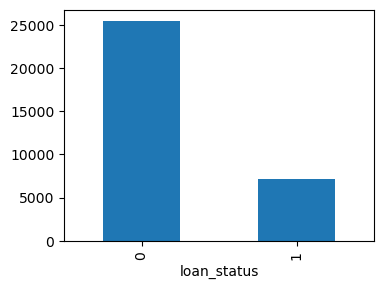

In [25]:
%matplotlib inline
# Creating Bar chart as the Target variable is Categorical
GroupedData=df.groupby('loan_status').size()
GroupedData.plot(kind='bar', figsize=(4,3))

### Though we have onl 80:20 ratio, we can still go ahead

## Duplicate data management

In [27]:
df[df.duplicated()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15975,23,42000,RENT,5.0,VENTURE,B,6000,9.99,0,0.14,N,4
15989,23,90000,MORTGAGE,7.0,EDUCATION,B,8000,10.36,0,0.09,N,3
15995,24,48000,MORTGAGE,4.0,MEDICAL,A,4000,5.42,0,0.08,N,4
16025,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,N,3
16028,23,100000,MORTGAGE,7.0,EDUCATION,A,15000,7.88,0,0.15,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.0,HOMEIMPROVEMENT,A,2500,5.42,0,0.06,N,12
32047,36,250000,RENT,2.0,DEBTCONSOLIDATION,A,20000,7.88,0,0.08,N,17
32172,49,120000,MORTGAGE,12.0,MEDICAL,B,12000,10.99,0,0.10,N,12
32259,39,40000,OWN,4.0,VENTURE,B,1000,10.37,0,0.03,N,16


In [28]:
print("Total Duplicated Values in dataframe are {0}".format(df[df.duplicated()].shape[0]))

Total Duplicated Values in dataframe are 165


### Let's confirm duplicate values if they are really fact

In [35]:
df.query("person_age==43 & person_income==11340 &\
person_home_ownership=='RENT' & loan_intent=='EDUCATION'")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
29484,43,11340,RENT,4.0,EDUCATION,C,1950,NaN,1,0.17,N,11
32279,43,11340,RENT,4.0,EDUCATION,C,1950,NaN,1,0.17,N,11


## Let's drop the duplicated values

In [6]:
df.drop_duplicates(inplace=True)

## Numerical Variable Analysis

In [41]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,31529.00000,32416.000000,29321.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.79051,9593.845632,11.017265,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.14549,6322.730241,3.241680,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.00000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.00000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.00000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.00000,12250.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.00000,35000.000000,23.220000,1.000000,0.830000,30.000000


### We could see, person_age max value is 144 Let's visualize it with boxplot

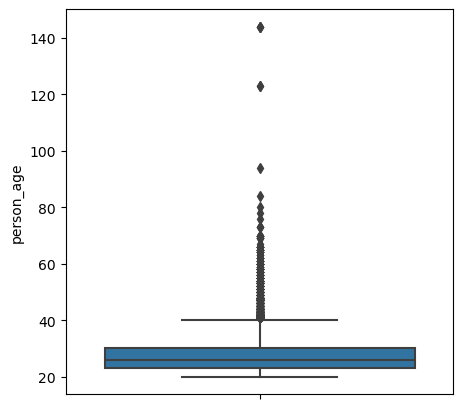

In [7]:
import seaborn as sns
plt.figure(figsize=(5,5))
boxplot = sns.boxplot(y="person_age", data=df)

In [44]:
df.query("person_age > 80")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25
32416,94,24000,RENT,1.0,MEDICAL,C,6500,NaN,0,0.27,N,27
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.51,0,0.11,N,24


### We can cap age above 84

In [50]:
df = df.query("person_age < 85")

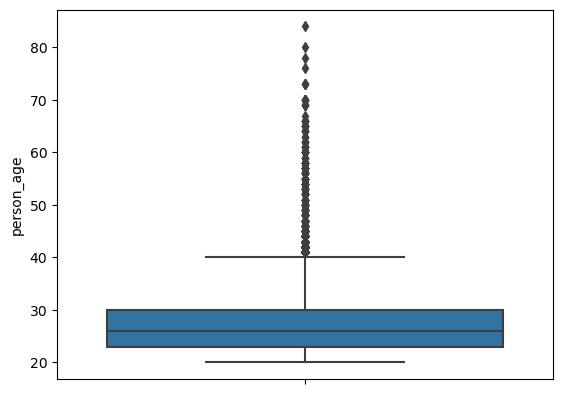

In [53]:
boxplot = sns.boxplot(y="person_age", data=df)

## Lets Look at employee Length

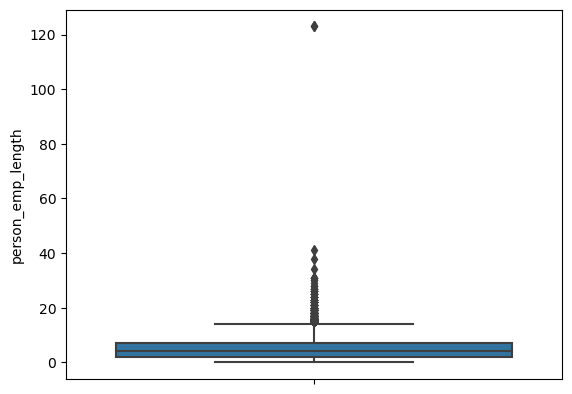

In [54]:
boxplot = sns.boxplot(y="person_emp_length", data=df)

### We could see one value at the top, seems to be outlier, lets confirm that

In [55]:
df.query("person_emp_length > 60")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


## Lets fill this value with nan and we would impute it later as only employee length seems to be wrognly entered

In [8]:
filter_con = df["person_emp_length"] > 60
df.loc[filter_con, 'person_emp_length'] = np.nan

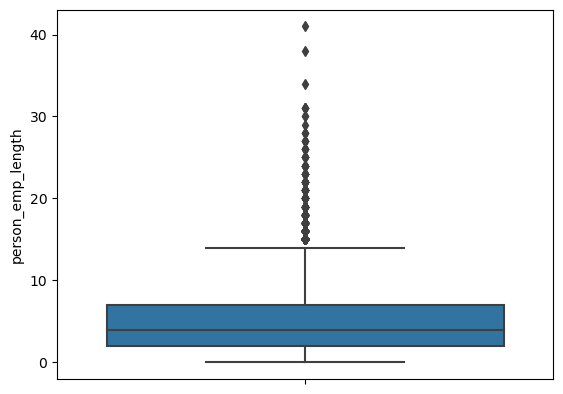

In [60]:
boxplot = sns.boxplot(y="person_emp_length", data=df)

In [64]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,NaN,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [65]:
35000 / 59000

0.5932203389830508

### Loan Percent income seems to be direct calculation of percent of salary, let's confirm

In [66]:
df["confirm_col_loan_percent_income"] = df['loan_amnt']/df['person_income']

In [74]:
df = df.round({"confirm_col_loan_percent_income":2}) 

In [80]:
df[df['confirm_col_loan_percent_income']!=df['loan_percent_income']]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,confirm_col_loan_percent_income
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.64
17,23,92111,RENT,7.0,MEDICAL,F,35000,20.25,1,0.32,N,4,0.38
36,22,48000,RENT,1.0,EDUCATION,E,30000,18.39,1,0.63,N,2,0.62
40,26,62050,RENT,6.0,MEDICAL,E,30000,17.99,1,0.41,N,2,0.48
48,22,66300,RENT,4.0,MEDICAL,B,30000,12.69,1,0.38,N,3,0.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32480,62,62050,MORTGAGE,29.0,MEDICAL,C,25000,13.43,1,0.34,Y,28,0.40
32485,64,24000,RENT,1.0,MEDICAL,A,3000,6.99,0,0.13,N,21,0.12
32542,67,200000,MORTGAGE,2.0,PERSONAL,C,3000,10.28,0,0.01,N,26,0.02
32555,51,80000,RENT,3.0,HOMEIMPROVEMENT,F,18000,18.78,0,0.23,Y,20,0.22


### Through query, we could confirm that, its not the straigh calculation and we can't drop the values

## Imputing Missing values

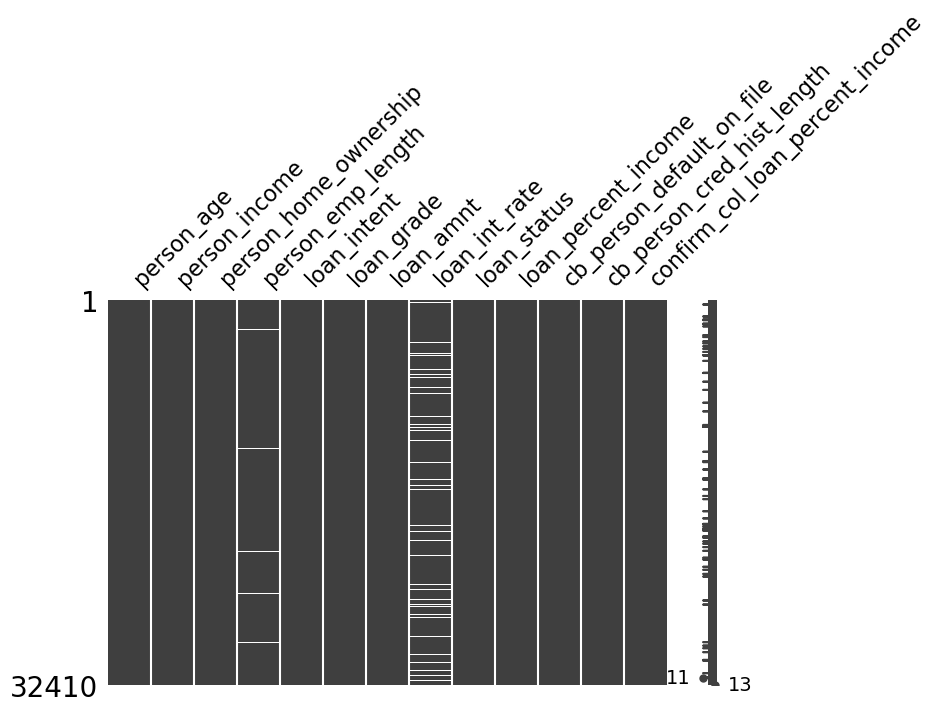

In [81]:
import missingno as msno
msno.matrix(df, figsize = (8,5));

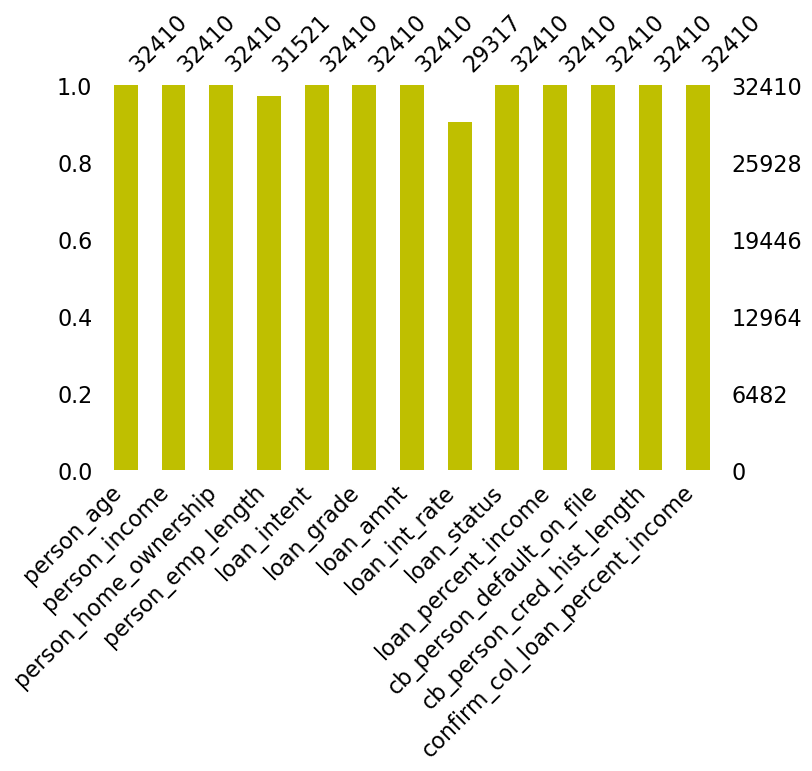

In [82]:
msno.bar(df, color = 'y', figsize = (8,5));

In [83]:
df.isna().sum()

person_age                            0
person_income                         0
person_home_ownership                 0
person_emp_length                   889
loan_intent                           0
loan_grade                            0
loan_amnt                             0
loan_int_rate                      3093
loan_status                           0
loan_percent_income                   0
cb_person_default_on_file             0
cb_person_cred_hist_length            0
confirm_col_loan_percent_income       0
dtype: int64

## The values are missing completely Random, we would use IterativeImputer to fill the missing value
## Fature Creation and Selection

### Lets Visualize person income by age

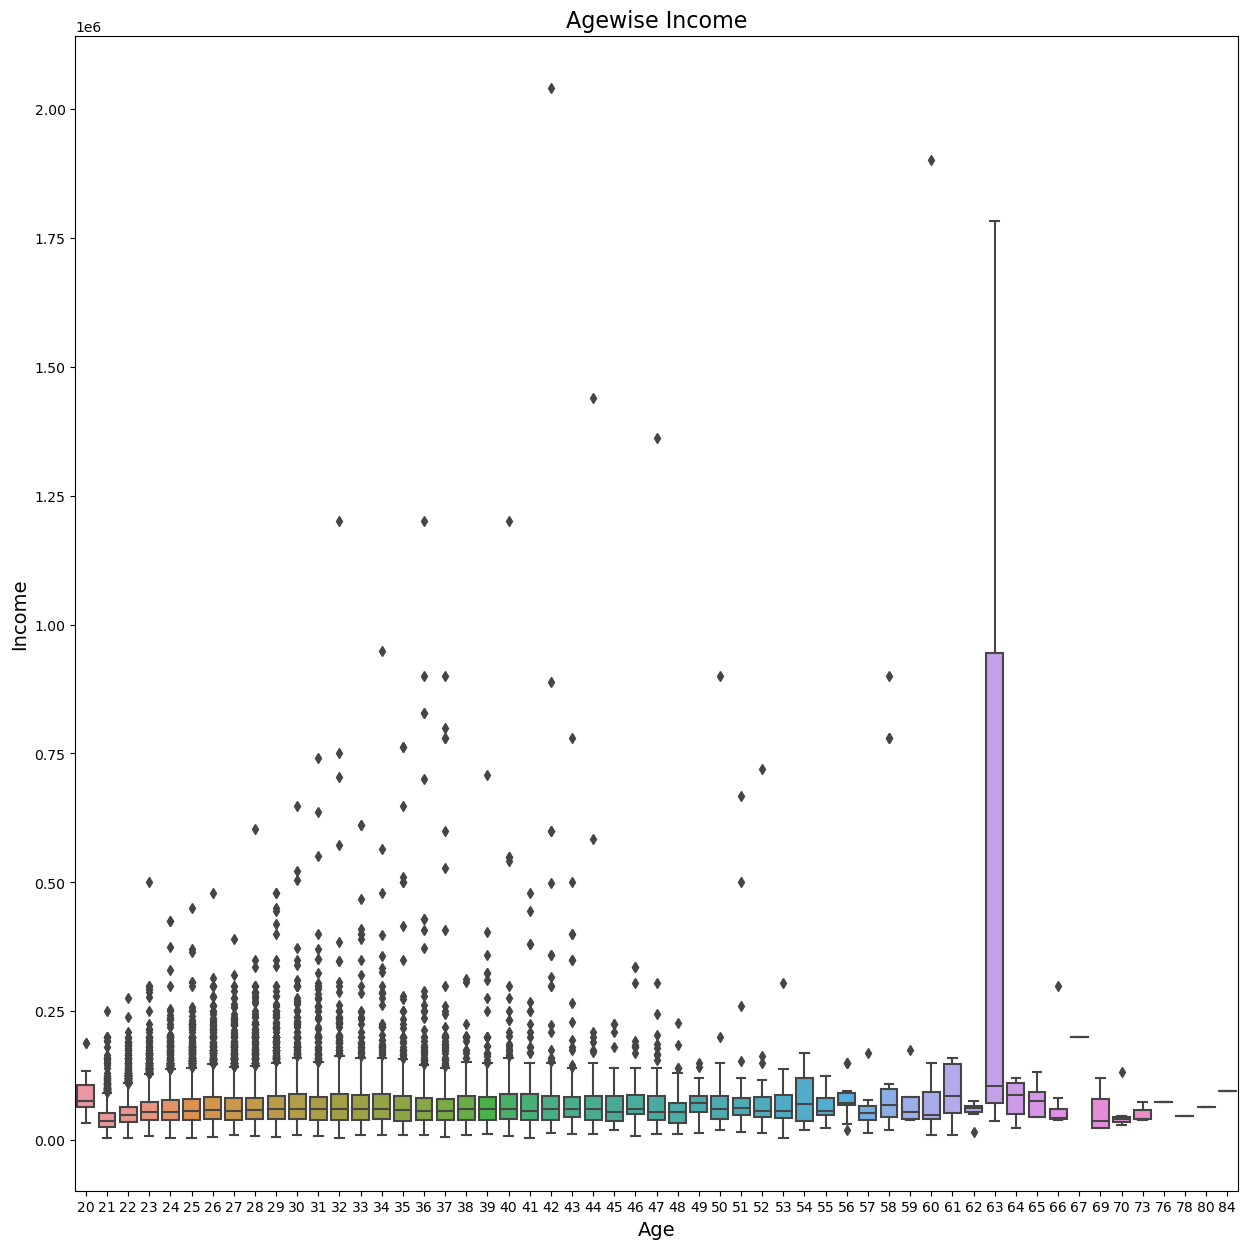

In [86]:
plt.figure(figsize=(15,15))
boxplot = sns.boxplot(x="person_age", y="person_income", data=df)
boxplot.axes.set_title("Agewise Income", fontsize=16)
boxplot.set_xlabel("Age", fontsize=14)
boxplot.set_ylabel("Income", fontsize=14)
plt.show()

### The Salaries seems to be normal, only concern on 63 age, lets check

In [88]:
df.query("person_age == 63")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,confirm_col_loan_percent_income
32394,63,37000,RENT,24.0,DEBTCONSOLIDATION,C,5450,15.96,1,0.15,N,22,0.15
32497,63,1782000,RENT,13.0,EDUCATION,C,12025,14.27,0,0.01,N,30,0.01
32514,63,106000,MORTGAGE,0.0,PERSONAL,C,11500,12.98,0,0.11,N,23,0.11


### 1782000 seems to be a outlier, but we will still keep it for now

In [90]:
df.query("person_income > 1500000")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,confirm_col_loan_percent_income
30049,42,2039784,RENT,0.0,VENTURE,C,8450,12.29,0,0.00,Y,15,0.00
32497,63,1782000,RENT,13.0,EDUCATION,C,12025,14.27,0,0.01,N,30,0.01
32546,60,1900000,MORTGAGE,5.0,PERSONAL,A,1500,NaN,0,0.00,N,21,0.00


### These records again seems to be a outliers, we will keep them as its as of now,
### We would apply capping technique to check if our model achieves any improvement

In [92]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,confirm_col_loan_percent_income
0,22,59000,RENT,NaN,PERSONAL,D,35000,16.02,1,0.59,Y,3,0.59
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.10
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.57
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.53
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.64


### Let's look at person income by person home owenrship

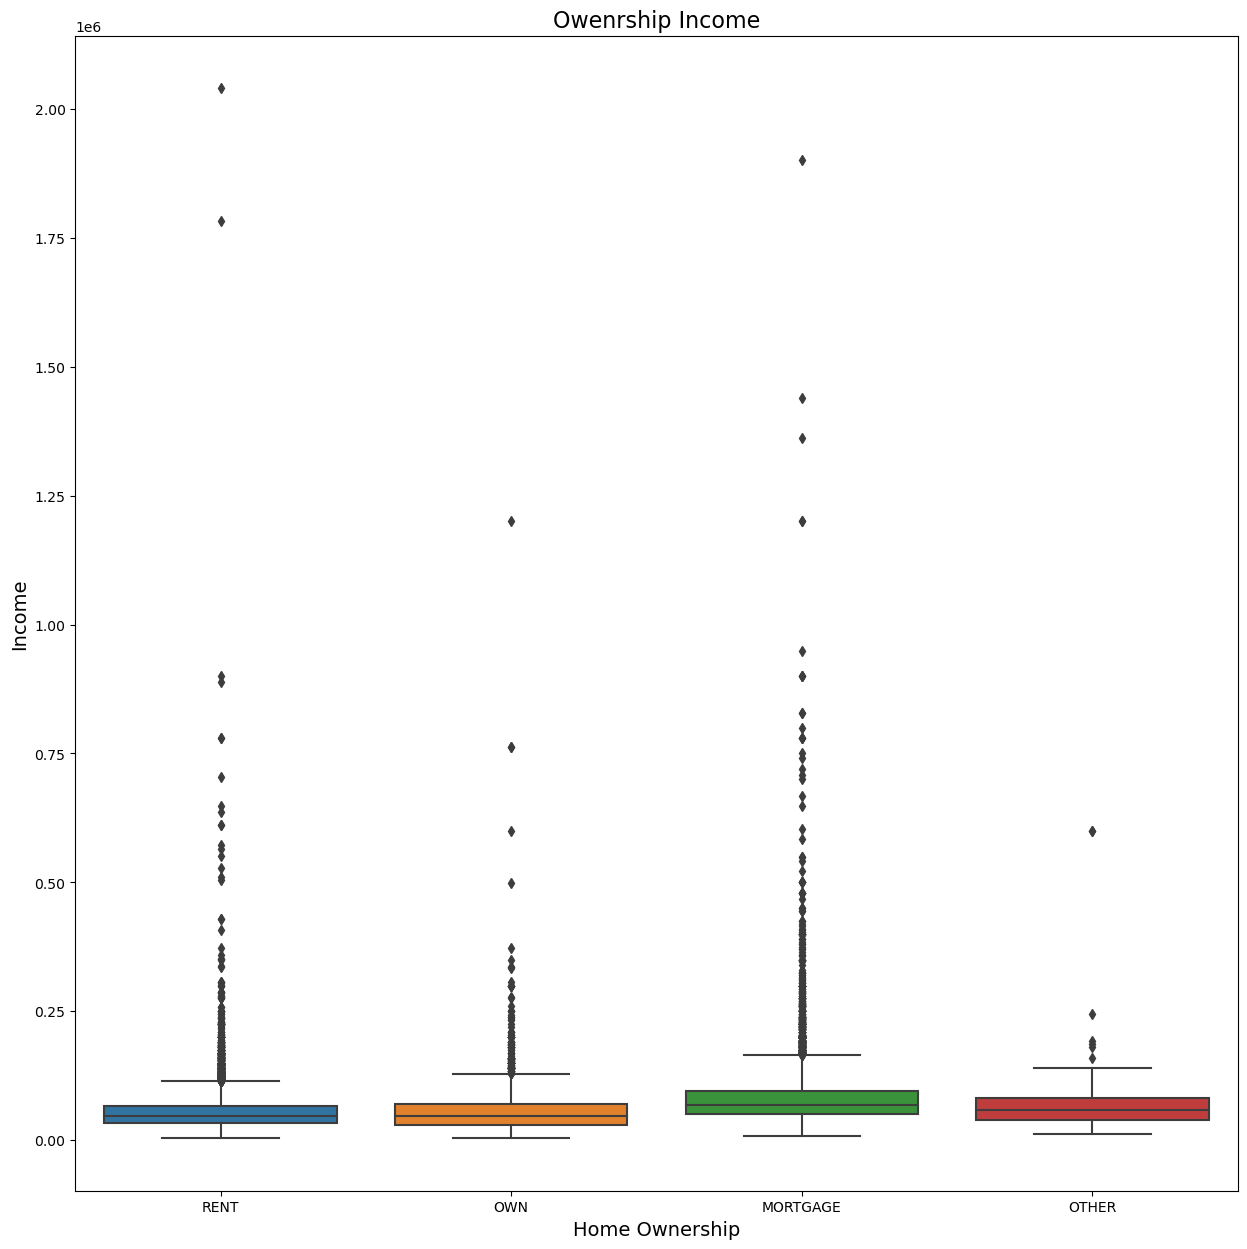

In [93]:
plt.figure(figsize=(15,15))
boxplot = sns.boxplot(x="person_home_ownership", y="person_income", data=df)
boxplot.axes.set_title("Owenrship Income", fontsize=16)
boxplot.set_xlabel("Home Ownership", fontsize=14)
boxplot.set_ylabel("Income", fontsize=14)
plt.show()

### 

In [ ]:
df.query("person_income == 63")

<AxesSubplot:ylabel='Frequency'>

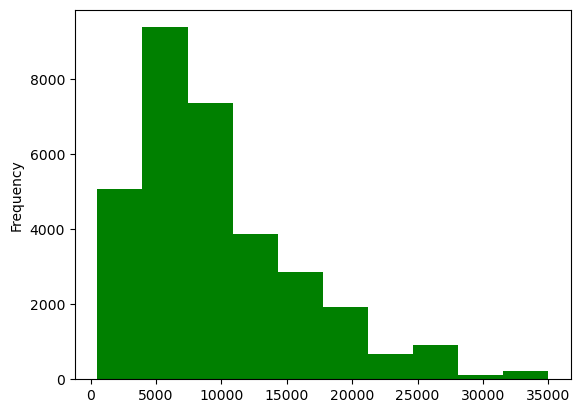

In [94]:
df['loan_amnt'].plot(kind='hist',color='g')

In [79]:
35000/54400

0.6433823529411765

In [37]:
cat_cols = [col for col in df.columns if df[col].dtype == "category" and col != 'loan_status']
num_cols = [col for col in df.columns if df[col].dtype != "category" and col != 'loan_status']

In [40]:
df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


## Let's create new Features

### 1. Higher Salary People
### Lets first group employee salary by age, then we will calculate upper whisker by calculating Q3 + (1.5) * IQR of that group
### For each employee, if that salary is above higher whisker then mark him as high salary person

In [9]:
def get_higher_whisker(grp):
    try:
        q1, q3 = grp.quantile(0.25), grp.quantile(0.75)
        iqr = q3 - q1
        higher_whisker = q3 + (1.5*iqr)
        return higher_whisker
    except Exception as e:
        print("------------Error Occured-----------")
        print(traceback.format_exc())

In [10]:
%%time
df["higher_whisker"] = df.groupby('person_age')['person_income'].transform(lambda x: get_higher_whisker(x))

CPU times: user 99 ms, sys: 1.56 ms, total: 101 ms
Wall time: 102 ms


In [12]:
%%time
df['higher_salary'] = df['person_income'] > df['higher_whisker']

CPU times: user 1.51 ms, sys: 0 ns, total: 1.51 ms
Wall time: 1.34 ms


In [13]:
pd.crosstab(df['loan_status'],df['higher_salary'])

higher_salary,False,True
loan_status,,
0,24019,1308
1,6959,130


### 2. Home owners would be bit of higher earning person or financial wel to do person.

In [14]:
%%time
df['home_owner'] = df['person_home_ownership']=='OWN'

CPU times: user 3.29 ms, sys: 39 µs, total: 3.33 ms
Wall time: 3.28 ms


In [16]:
pd.crosstab(df['loan_status'],df['home_owner'])

home_owner,False,True
loan_status,,
0,22956,2371
1,6897,192


### 3. Employee having long services tend to be well to do 

In [17]:
df['long_working'] = df['person_emp_length'] > 10

In [18]:
pd.crosstab(df['loan_status'],df['long_working'])

long_working,False,True
loan_status,,
0,22884,2443
1,6616,473


### 4. Employee having very low loan requirement, tend to get loan approved easily

In [19]:
df['loan_percent_calc'] = (df['loan_amnt'] / df['person_income'])*100
df['lower_loan_requirement'] =  df['loan_percent_calc'] < 20

In [20]:
pd.crosstab(df['loan_status'],df['lower_loan_requirement'])

lower_loan_requirement,False,True
loan_status,,
0,6611,18716
1,4226,2863


In [21]:
df['higher_loan_requirement'] =  df['loan_percent_calc'] > 40

In [22]:
pd.crosstab(df['loan_status'],df['higher_loan_requirement'])

higher_loan_requirement,False,True
loan_status,,
0,25026,301
1,6200,889


In [24]:
cat_cols.append(['higher_salary','home_owner','long_working','lower_loan_requirement','higher_loan_requirement'])

In [26]:
cat_cols = ['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file',
 'higher_salary',
  'home_owner',
  'long_working',
  'lower_loan_requirement',
  'higher_loan_requirement']

## Check Statistical Significant Relation with Output variable ( Feature Selection )

## Corelation of Categorical Predictor Vs Categorical Output Variable 
### Categorical Vs Categorical variable relation will be tested by Box Plot interpretation

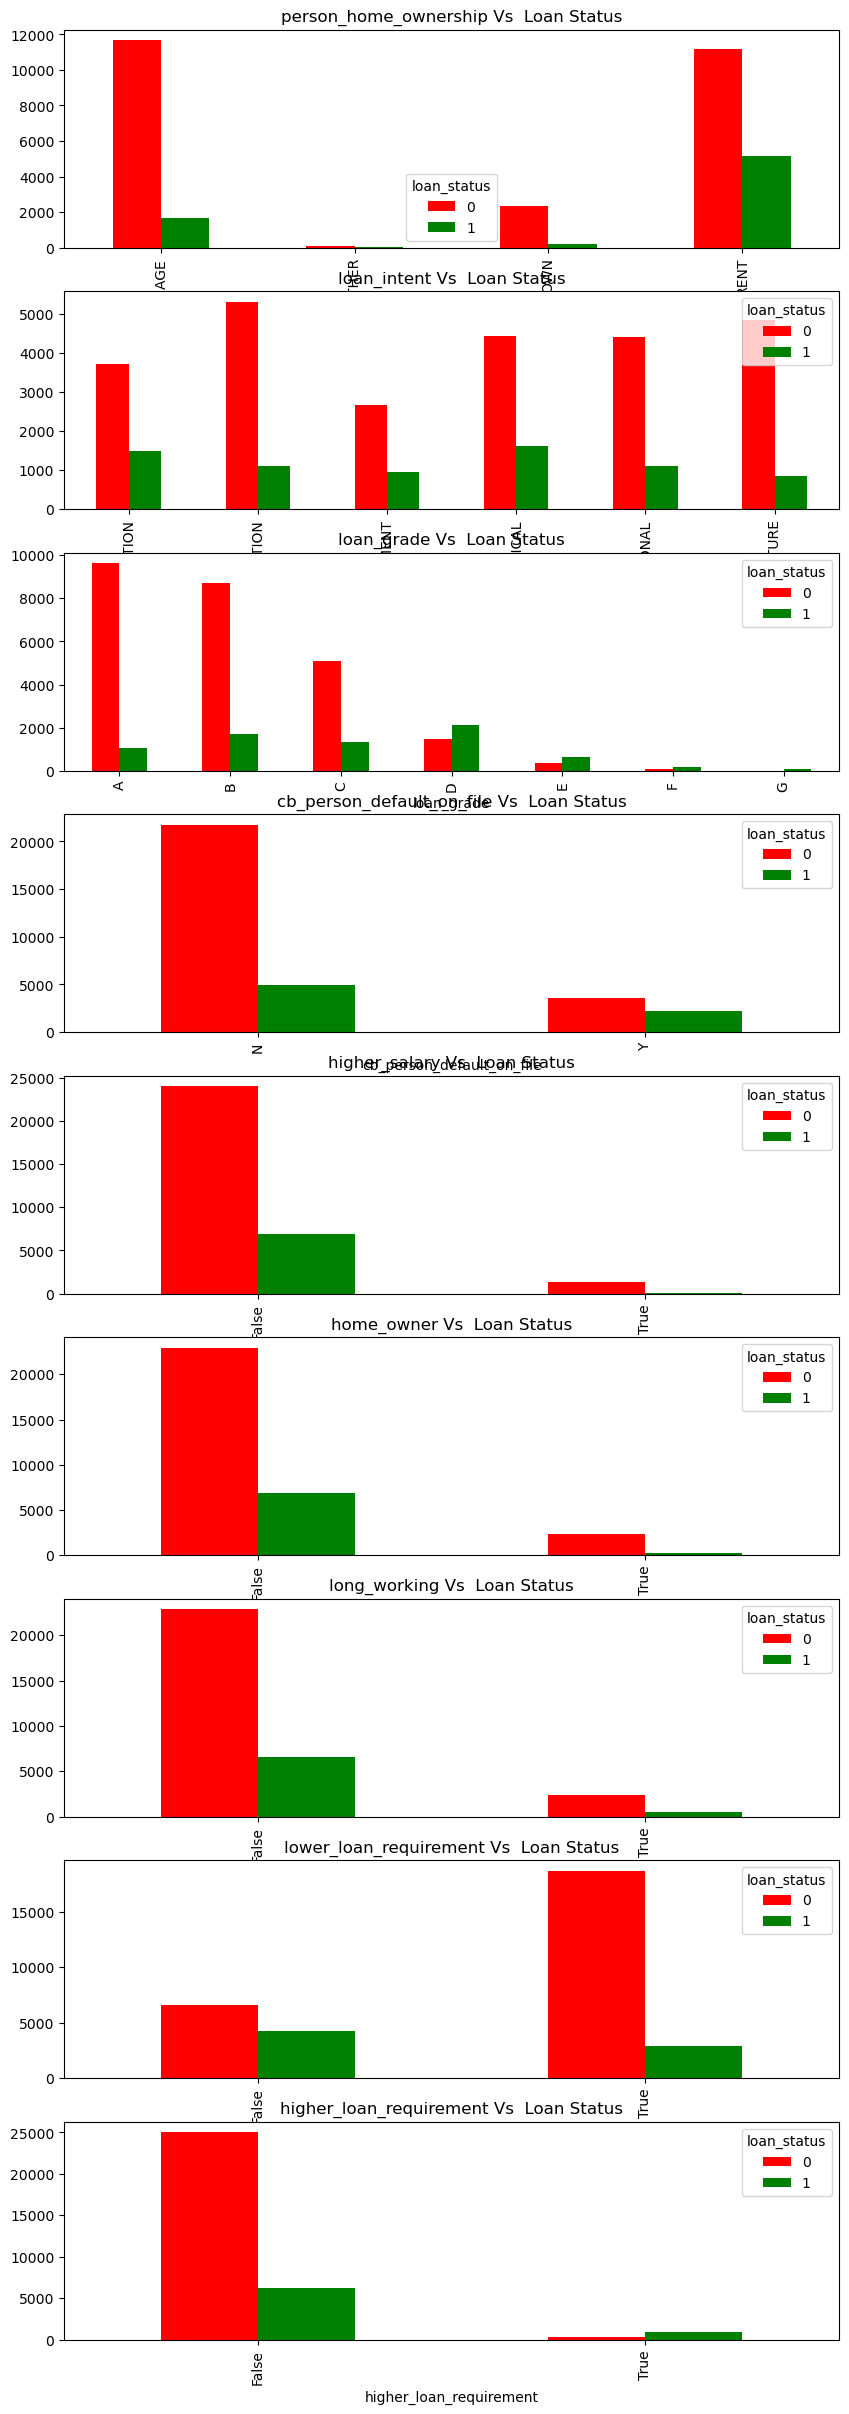

In [27]:
fig, plt_convas=plt.subplots(nrows=len(cat_cols), ncols=1, figsize=(10,30))
zipped_cols = zip(cat_cols, range(len(cat_cols)))
for col,i in zipped_cols:
    crosstab_loan_status = pd.crosstab(index=df[col], columns=df['loan_status'])
    crosstab_loan_status.plot.bar(color=['red','green'], ax=plt_convas[i], title=col+' Vs '+' Loan Status')

### Box Plot interpration
### 1. Grouped barplots generally shows the frequencies of category against output variables, on the X axis there is categories and Y axis shows frequencies.
### 2. If the ratio of bars is similar across all categories, then the two columns are not correlated.
### 3. We will confirm this with Chi Square test

In [28]:
from scipy.stats import chi2_contingency
cols_selected = []
for col in cat_cols:
    crosstab_loan_status = pd.crosstab(index=df[col], columns=df['loan_status'])
    chi_square_res = chi2_contingency(crosstab_loan_status)
    if(chi_square_res[1] < 0.05):
        print(col," is Corealted with Loan Status variable.")
        cols_selected.append(col)

cols_selected

person_home_ownership  is Corealted with Loan Status variable.
loan_intent  is Corealted with Loan Status variable.
loan_grade  is Corealted with Loan Status variable.
cb_person_default_on_file  is Corealted with Loan Status variable.
higher_salary  is Corealted with Loan Status variable.
home_owner  is Corealted with Loan Status variable.
long_working  is Corealted with Loan Status variable.
lower_loan_requirement  is Corealted with Loan Status variable.
higher_loan_requirement  is Corealted with Loan Status variable.


['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file',
 'higher_salary',
 'home_owner',
 'long_working',
 'lower_loan_requirement',
 'higher_loan_requirement']

### As per aboove results, we can select person_home_ownership, loan_intent, loan_grade, cb_person_default_on_file variables can be considered for modelling, as they have good corelation
## Corelation of Contineous Predictor Vs Categorical Output Variable 
### Lets now check for numerical variable correlation with output variable 
### 1. We will first check the box plot visualiazation and then we will use ANOVA to confirm our findings

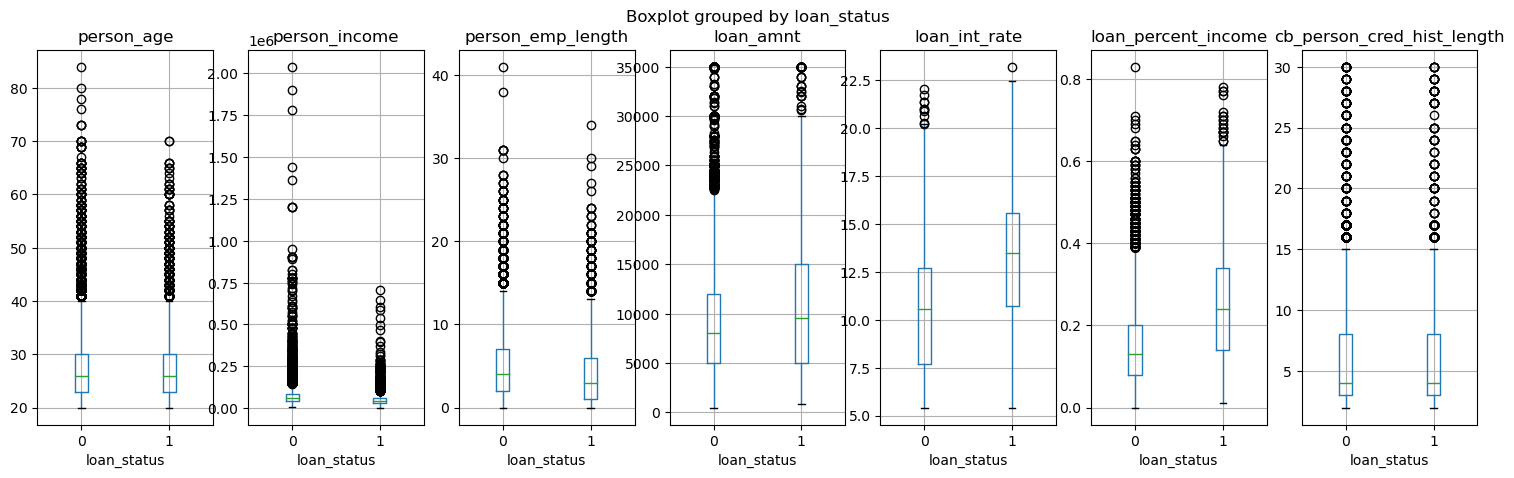

In [98]:
fig, plot_canvas = plt.subplots(nrows=1, ncols=len(num_cols), figsize=(18,5))

for col , i in zip(num_cols, range(len(num_cols))):
    df.boxplot(column=col, by='loan_status', figsize=(5,5), vert=True, ax=plot_canvas[i])

### Lets confirm with ANOVA

In [99]:
from scipy.stats import f_oneway
cols_selected = []
for col in num_cols:
    datagrouped = df.groupby("loan_status")[col].apply(list)
    anova_res = f_oneway(*datagrouped)
    print(col,':', anova_res[1])
    if(anova_res[1] < 0.05):
        print(col," is Corealted with Loan Status variable.")
        cols_selected.append(col)
    else:
        print(anova_res)

cols_selected

person_age : 9.543699813109633e-05
person_age  is Corealted with Loan Status variable.
person_income : 5.815092040569517e-207
person_income  is Corealted with Loan Status variable.
person_emp_length : nan
F_onewayResult(statistic=nan, pvalue=nan)
loan_amnt : 2.8689731047140306e-81
loan_amnt  is Corealted with Loan Status variable.
loan_int_rate : nan
F_onewayResult(statistic=nan, pvalue=nan)
loan_percent_income : 0.0
loan_percent_income  is Corealted with Loan Status variable.
cb_person_cred_hist_length : 0.0031622566087652413
cb_person_cred_hist_length  is Corealted with Loan Status variable.


['person_age',
 'person_income',
 'loan_amnt',
 'loan_percent_income',
 'cb_person_cred_hist_length']

## Feature Selection Summary
### We have finally selected person_home_ownership, loan_intent, loan_grade, cb_person_default_on_file as Categorical Features
### We have finally selected 'person_age','person_income','loan_amnt','loan_percent_income','cb_person_cred_hist_length' as Numerical features

## Lets define our strategy for Classification ML Process
<ul>
    <li><b>Read Train Dataframe</b></li>
    
    <li><b>Convert all the cateogorical values datatype to category</b></li>
    <li><b>Drop Duplicate</b></li>
    <li><b>Get age only below 80</b></li>
    <li><b>Cap person_emp_length to only 60 and put nan for all aove values</b></li>
    <li><b>Impute Missing Values for numerical variable</b></li>
    <li><b>Scale numerical variable.</b></li>
    <li><b>Encode all categorical variable.</b></li>
    <li><b>Apply model and plot confusion matrix. </b></li>
    <li><b>Check balenced Accuracy , plot Learning curve and ROC curve </b></li>
    <li><b>Hypertune the model, cmpare each model and finalize</b></li>
</ul>

In [5]:
from sklearn.model_selection import ( train_test_split, KFold, StratifiedKFold,cross_val_score, RepeatedKFold, RandomizedSearchCV,learning_curve, ShuffleSplit, GridSearchCV)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import (IterativeImputer, SimpleImputer, KNNImputer)
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (AdaBoostRegressor, RandomForestClassifier, RandomForestRegressor)
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( confusion_matrix , ConfusionMatrixDisplay, balanced_accuracy_score, roc_auc_score)
import plotly.graph_objects as go
import re
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMClassifier
import matplotlib.pylab as plt
np.seterr(divide = 'ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [6]:
class SelectColumnsTransformer():
    #The parameter "columns" is set and only those columns will be resulted 
    def __init__(self, columns=None):
        self.columns = columns
        
    #Transformer function will copy only those columns which has better corelation with output variable
    def transform(self, X, **transform_params):
        cpy_df = X[self.columns].copy()
        return cpy_df

    def fit(self, X, y=None, **fit_params):
        return self

In [7]:
class DataframeFunctionTransformer():
    def __init__(self, func):
        self.func = func

    def transform(self, input_df, **transform_params):
        return self.func(input_df)

    def fit(self, X, y=None, **fit_params):
        return self

In [8]:
class ml_support():
    def __init__(self):
        self.df = pd.read_csv("/kaggle/input/credit-risk-dataset/credit_risk_dataset.csv", encoding='latin')
        self.output_var = 'loan_status'
        self.num_cols = ['person_age','person_income','loan_amnt','loan_percent_income','cb_person_cred_hist_length']
        self.cat_cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file','higher_salary','home_owner','long_working','lower_loan_requirement','higher_loan_requirement']
        # These are columns without feature engineering
        self.cols_wofeature = [col for col in self.df.columns if col != self.output_var ]
        # These are coluns after feature engineering
        self.cols_wfeature = ['person_age','person_income','loan_amnt','loan_percent_income','cb_person_cred_hist_length','person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file','higher_salary','home_owner','long_working','lower_loan_requirement','higher_loan_requirement']
        self.X = self.df[self.cols_wofeature]
        #Output variable
        self.y = self.df[self.output_var]
        self.random_state = 42
    
    def drop_duplicate(self):
        
        self.df.drop_duplicates(inplace=True)
        return self.df
    
    def get_train_test_data(self):
        
        #Split traininig and testing set
        X_train, X_test , y_train, y_test = train_test_split(self.X,self.y,test_size=0.2,
                                                             random_state = self.random_state, shuffle=True, stratify=self.df[self.output_var])
        return X_train, X_test , y_train, y_test
    
    def get_column_transformer(self,is_estimator, iterative_Estimator, is_TreeBased=False):
        
        #Pipineline created for munging numerical columns
        num_pipeline_steps = []
        iterative_imputer = IterativeImputer()
        if is_estimator:
            iterative_imputer = IterativeImputer(estimator=iterative_Estimator)
        
        num_pipeline_steps.append(('num_missing',iterative_imputer))
        
        if not is_TreeBased:
            num_pipeline_steps.append(('num_smoothening',PowerTransformer()))
        
        num_pipeline = Pipeline(num_pipeline_steps)
        
        #Pipineline created for categorical column encoding
        cat_pipeline = Pipeline([
            ('cat_encoding',OneHotEncoder(sparse=False,drop='if_binary',handle_unknown='ignore'))
        ])
        
        # Column Transformer is created which will call pipelines
        ct = ColumnTransformer([
            ('num_munging',num_pipeline,self.num_cols),
            ('cat_munging',cat_pipeline,self.cat_cols)
        ])
        return ct
    
    def get_final_pipeline(self,regression_model,columntransformer, feature_engieered):
    
        X_train, X_test , y_train, y_test  = self.get_train_test_data()
        features_pipeline = [feature_engieered]
        features_pipeline.append(("selector", SelectColumnsTransformer(self.cols_wfeature)))
        features_pipeline.append(('munging',columntransformer))
        features_pipeline.append(('model',regression_model))
        finalized_pipeline = Pipeline(features_pipeline)
        return finalized_pipeline;
    
    def predit_with_pipeline(self,pipeline,X_train,X_test,y_train):
        pipeline.fit(X_train,y_train)
        preds = pipeline.predict(X_test)
        return preds
    
    def get_best_params(self,pipeline,params):
    
        rscv = RandomizedSearchCV(pipeline, params, scoring='balanced_accuracy',
                              n_jobs=-1, n_iter=4, cv=5, random_state=self.random_state, verbose=3)
        rscv.fit(self.X,self.y)
        return rscv.best_params_

    def get_best_params_gcv(self,pipeline,params):
    
        rscv = GridSearchCV(pipeline, params, scoring='balanced_accuracy',
                              n_jobs=-1, cv=5, verbose=3)
        rscv.fit(self.X,self.y)
        return rscv.best_params_
    
    def plot_confusion_matrix(self,y_test, preds, finalized_pipeline):
    
        cm = confusion_matrix(y_test, preds, labels=finalized_pipeline.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels= finalized_pipeline.classes_)
        disp.plot();
        plt.show();
        
    def update_performance_matrics(self,model_info,df):
        
        filter_con =  df["Model_Name"] == model_info['Model_Name']
        if ((filter_con)).any():
            df.loc[filter_con, 'Score'] = model_info['Score']
        else:
            df = df.append(model_info, ignore_index=True)
        return df
    
    def plot_learning_curves(self,estimator):
        """
        Don't forget to change the scoring and plot labels
        based on the metric that you are using.
        """
        train_sizes, train_scores, test_scores = learning_curve(
            estimator=estimator,
            X=self.X,
            y=self.y,
            train_sizes=np.linspace(0.1, 1.0, 5),
            cv=5,
            scoring="balanced_accuracy",
            random_state=self.random_state,
            n_jobs=-1
        )
        train_mean = np.mean(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        fig = go.Figure()
        fig.add_trace(
            go.Scatter(
                x=train_sizes,
                y=train_mean,
                name="Training Accuracy",
                mode="lines",
                line=dict(color="blue"),
            )
        )
        fig.add_trace(
            go.Scatter(
                x=train_sizes,
                y=test_mean,
                name="Validation Accuracy",
                mode="lines",
                line=dict(color="green"),
            )
        )
        fig.update_layout(
            title="Learning Curves",
            xaxis_title="Number of training examples",
            yaxis_title="Balenced Accuracy",
        )
        fig.show()

In [9]:
def get_higher_whisker(grp):
    try:
        q1, q3 = grp.quantile(0.25), grp.quantile(0.75)
        iqr = q3 - q1
        higher_whisker = q3 + (1.5*iqr)
        return higher_whisker
    except Exception as e:
        print("------------Error Occured-----------")
        print(traceback.format_exc())
        
def impute_higher_salary(df):
    
    df["higher_whisker"] = df.groupby('person_age')['person_income'].transform(lambda x: get_higher_whisker(x))
    df['higher_salary'] = df['person_income'] > df['higher_whisker']
    return df;

def define_home_owner(df):
    df['home_owner'] = df['person_home_ownership']=='OWN'
    return df

def define_loan_percentage(df):
    df['loan_percent_calc'] = (df['loan_amnt'] / df['person_income'])*100
    return df

def define_lower_loan_requirement(df):
    df['lower_loan_requirement'] =  df['loan_percent_calc'] < 20
    return df

def define_higher_loan_requirement(df):
    df['higher_loan_requirement'] =  df['loan_percent_calc'] > 40
    return df

def define_long_employement(df):
    df['long_working'] = df['person_emp_length'] > 10
    return df

def impute_empty_to_wrong_age(df):
        
    filter_con = df["person_age"] > 85
    df.loc[filter_con, 'person_age'] = np.nan
    return df

def impute_empty_to_wrong_employee_len(df):

    filter_con = df["person_emp_length"]  > 60
    df.loc[filter_con, 'person_emp_length'] = np.nan
    return df

def add_features(df):
    df = impute_empty_to_wrong_age(df)
    df = impute_empty_to_wrong_employee_len(df)
    df = impute_higher_salary(df)
    df = define_home_owner(df)
    df = define_loan_percentage(df)
    df = define_lower_loan_requirement(df)
    df = define_higher_loan_requirement(df)
    df = define_long_employement(df)
    return df

In [10]:
feature_engieered = ("FeatureEngineering_add_features", DataframeFunctionTransformer(add_features))

In [12]:
%%time
ml_support_obj = ml_support()
regression_model = LogisticRegression(n_jobs=-1,max_iter=1000)
ct = ml_support_obj.get_column_transformer(False, "", False)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 78.1 ms, sys: 27.1 ms, total: 105 ms
Wall time: 159 ms


In [13]:
%%time
preds = ml_support_obj.predit_with_pipeline(finalized_pipeline,X_train,X_test,y_train)

CPU times: user 951 ms, sys: 443 ms, total: 1.39 s
Wall time: 2.03 s


In [14]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

Balenced Accuracy Score : 0.7457046082243284


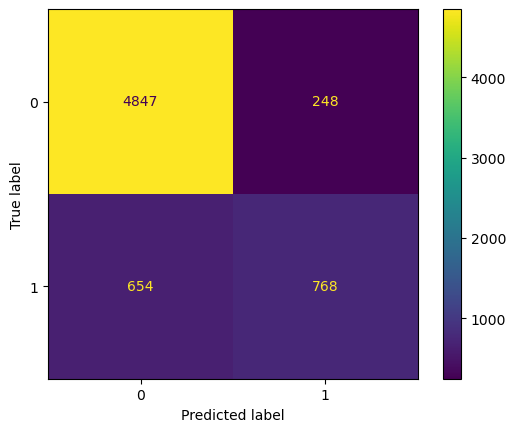

In [15]:
ml_support_obj.plot_confusion_matrix(y_test, preds, finalized_pipeline)

In [16]:
%%time
ml_support_obj.plot_learning_curves(finalized_pipeline)

CPU times: user 1.08 s, sys: 76.9 ms, total: 1.16 s
Wall time: 8.13 s


In [17]:
df_modelPerformance = pd.DataFrame(columns=['Model_Name','Model_Pipeline','Score'])
dict_Baseline_Score = {
                "Model_Name" : "Baseline Logistic Regression",
                "Model_Pipeline" : [finalized_pipeline],
                "Score": balanced_accuracy_score(y_test, preds)
               }
df_modelPerformance = ml_support_obj.update_performance_matrics(dict_Baseline_Score,df_modelPerformance)
df_modelPerformance.sort_values('Score',ascending=False)

,Model_Name,Model_Pipeline,Score
0,Baseline Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745705


In [19]:
%%time
regression_model = LogisticRegression(n_jobs=-1)
params = {"munging__num_munging__num_missing__estimator": [LinearRegression(), RandomForestRegressor(random_state=0),KNeighborsRegressor()],
          "model__penalty":["l1", "l2", "none"],
          "model__C" : np.logspace(-4, 4, 20),
          "model__solver": ["newton-cg","lbfgs","liblinear","sag","saga"],
          "model__max_iter" : [100, 1000,2500, 5000]
        }
ct = ml_support_obj.get_column_transformer(False, "")
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 39.8 ms, sys: 1.73 ms, total: 41.5 ms
Wall time: 40.4 ms


In [20]:
%%time
best_params = ml_support_obj.get_best_params(finalized_pipeline,params)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 4/5] END model__C=1438.44988828766, model__max_iter=2500, model__penalty=l2, model__solver=sag, munging__num_munging__num_missing__estimator=LinearRegression();, score=0.746 total time=   1.6s
[CV 5/5] END model__C=1438.44988828766, model__max_iter=2500, model__penalty=l2, model__solver=sag, munging__num_munging__num_missing__estimator=LinearRegression();, score=0.695 total time=  18.3s
[CV 3/5] END model__C=0.08858667904100823, model__max_iter=100, model__penalty=none, model__solver=lbfgs, munging__num_munging__num_missing__estimator=RandomForestRegressor(random_state=0);, score=0.706 total time=  39.5s


/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encounte

CPU times: user 2 s, sys: 47 ms, total: 2.05 s
Wall time: 1min 21s


In [21]:
best_params

{'munging__num_munging__num_missing__estimator': LinearRegression(),
 'model__solver': 'sag',
 'model__penalty': 'l2',
 'model__max_iter': 2500,
 'model__C': 1438.44988828766}

In [22]:
%%time
ml_support_obj = ml_support()
regression_model = LogisticRegression(n_jobs=-1,solver='sag',
                                      penalty='none',C=1438.44988828766,
                                      max_iter=2500)
ct = ml_support_obj.get_column_transformer(True, LinearRegression(n_jobs=-1))
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 80.8 ms, sys: 9.12 ms, total: 90 ms
Wall time: 90.7 ms


In [23]:
%%time
preds = ml_support_obj.predit_with_pipeline(finalized_pipeline,X_train,X_test,y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:1484: UserWarning:

Setting penalty='none' will ignore the C and l1_ratio parameters



CPU times: user 1.33 s, sys: 7.12 ms, total: 1.34 s
Wall time: 1.34 s


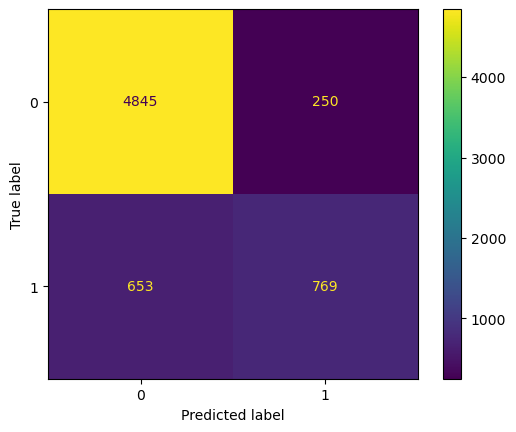

In [24]:
ml_support_obj.plot_confusion_matrix(y_test, preds, finalized_pipeline)

In [25]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

Balenced Accuracy Score : 0.7458599548107753


In [44]:
%%time
ml_support_obj.plot_learning_curves(finalized_pipeline)

CPU times: user 776 ms, sys: 89 ms, total: 865 ms
Wall time: 1min 13s


In [26]:
dict_Baseline_Score = {
                "Model_Name" : "Hyper Tuned Logistic Regression",
                "Model_Pipeline" : [finalized_pipeline],
                "Score": balanced_accuracy_score(y_test, preds)
               }
df_modelPerformance = ml_support_obj.update_performance_matrics(dict_Baseline_Score,df_modelPerformance)
df_modelPerformance.sort_values('Score',ascending=False)

,Model_Name,Model_Pipeline,Score
1,Hyper Tuned Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745860
0,Baseline Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745705


In [27]:
%%time
ml_support_obj = ml_support()
regression_model = DecisionTreeClassifier(random_state=0)
ct = ml_support_obj.get_column_transformer(False, "", True)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 91.2 ms, sys: 9.88 ms, total: 101 ms
Wall time: 108 ms


In [28]:
%%time
preds = ml_support_obj.predit_with_pipeline(finalized_pipeline,X_train,X_test,y_train)

CPU times: user 892 ms, sys: 312 ms, total: 1.2 s
Wall time: 657 ms


In [29]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

Balenced Accuracy Score : 0.8312278384395501


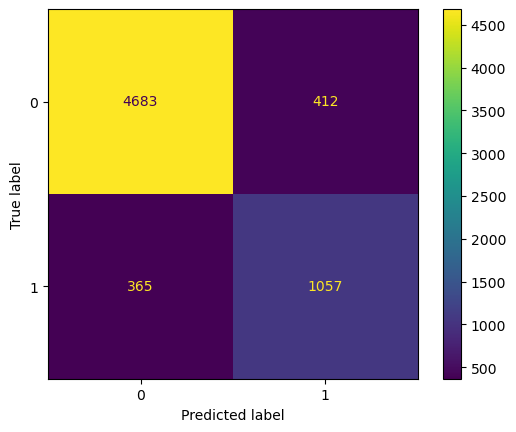

In [30]:
ml_support_obj.plot_confusion_matrix(y_test, preds, finalized_pipeline)

In [31]:
%%time
ml_support_obj.plot_learning_curves(finalized_pipeline)

CPU times: user 832 ms, sys: 60.6 ms, total: 893 ms
Wall time: 4.74 s


In [32]:
dict_Baseline_Score = {
                "Model_Name" : "Baseline Decision Tree Logistic",
                "Model_Pipeline" : [finalized_pipeline],
                "Score": balanced_accuracy_score(y_test, preds)
               }
df_modelPerformance = ml_support_obj.update_performance_matrics(dict_Baseline_Score,df_modelPerformance)
df_modelPerformance.sort_values('Score',ascending=False)

,Model_Name,Model_Pipeline,Score
2,Baseline Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.831228
1,Hyper Tuned Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745860
0,Baseline Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745705


In [33]:
%%time
ml_support_obj = ml_support()
regression_model = DecisionTreeClassifier(random_state=42)
params = {"munging__num_munging__num_missing__estimator": [LinearRegression(n_jobs=-1), RandomForestRegressor(random_state=42),KNeighborsRegressor(n_jobs=-1)],
          "model__criterion":["gini", "entropy","log_loss"],
          "model__splitter" : ["best", "random"],
          "model__max_depth" : range(1,10),
          "model__min_samples_split": range(1,10),
          "model__min_samples_leaf": range(1,5),
          "model__max_features":["auto","sqrt","log2",None]
         }
ct = ml_support_obj.get_column_transformer(False, "", True)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 96.4 ms, sys: 11.6 ms, total: 108 ms
Wall time: 109 ms


In [34]:
%%time
best_params = ml_support_obj.get_best_params(finalized_pipeline,params)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning:


10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.7/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py", line 394, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/opt/conda/lib/python3.7/site-packages/sklearn/tree/_classes.py", line 942, in fit
    X_idx_sorted=X_idx_sorted,
  File "/opt/conda/lib/python3.7/site-packages/s

CPU times: user 1.07 s, sys: 38.3 ms, total: 1.11 s
Wall time: 3.53 s


In [35]:
best_params

{'munging__num_munging__num_missing__estimator': KNeighborsRegressor(n_jobs=-1),
 'model__splitter': 'best',
 'model__min_samples_split': 9,
 'model__min_samples_leaf': 4,
 'model__max_features': None,
 'model__max_depth': 1,
 'model__criterion': 'gini'}

In [36]:
%%time
ml_support_obj = ml_support()
regression_model = DecisionTreeClassifier(random_state=42,splitter='best',
                                         min_samples_split=8,min_samples_leaf=4,
                                         max_features='auto',max_depth=9,criterion='gini')
ct = ml_support_obj.get_column_transformer(True, KNeighborsRegressor(n_jobs=-1), True)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 79.8 ms, sys: 8.09 ms, total: 87.9 ms
Wall time: 87 ms


In [37]:
%%time
preds = ml_support_obj.predit_with_pipeline(finalized_pipeline,X_train,X_test,y_train)

CPU times: user 457 ms, sys: 3.71 ms, total: 460 ms
Wall time: 467 ms


In [38]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

Balenced Accuracy Score : 0.7340269064980559


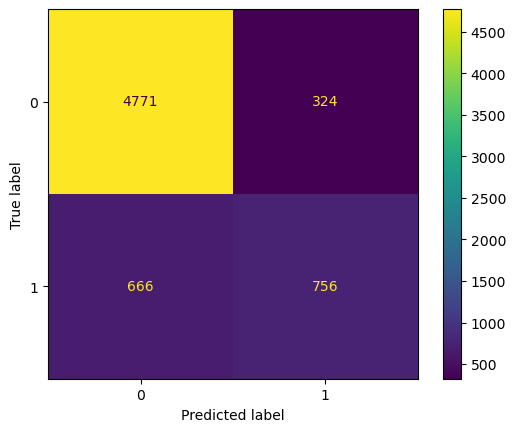

In [39]:
ml_support_obj.plot_confusion_matrix(y_test, preds, finalized_pipeline)

In [59]:
%%time
ml_support_obj.plot_learning_curves(finalized_pipeline)

CPU times: user 751 ms, sys: 25.7 ms, total: 777 ms
Wall time: 4.91 s


In [40]:
dict_Baseline_Score = {
                "Model_Name" : "Hypertuned Decision Tree Logistic",
                "Model_Pipeline" : [finalized_pipeline],
                "Score": balanced_accuracy_score(y_test, preds)
               }
df_modelPerformance = ml_support_obj.update_performance_matrics(dict_Baseline_Score,df_modelPerformance)
df_modelPerformance.sort_values('Score',ascending=False)

,Model_Name,Model_Pipeline,Score
2,Baseline Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.831228
1,Hyper Tuned Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745860
0,Baseline Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745705
3,Hypertuned Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.734027


In [42]:
%%time
ml_support_obj = ml_support()
regression_model = RandomForestClassifier(random_state = 42)
ct = ml_support_obj.get_column_transformer(False, "", True)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 77.2 ms, sys: 8.84 ms, total: 86.1 ms
Wall time: 86.6 ms


In [43]:
%%time
preds = ml_support_obj.predit_with_pipeline(finalized_pipeline,X_train,X_test,y_train)

CPU times: user 4.04 s, sys: 348 ms, total: 4.38 s
Wall time: 3.86 s


In [44]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

Balenced Accuracy Score : 0.8435619847372496


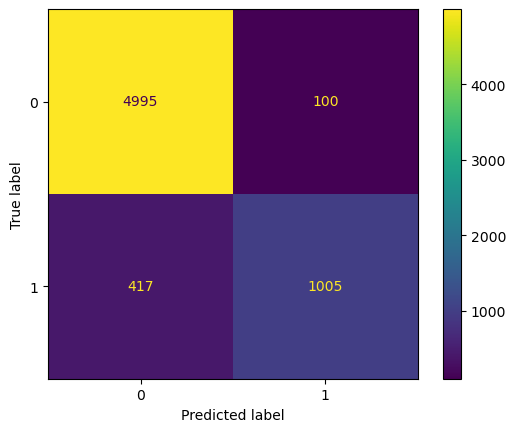

In [45]:
ml_support_obj.plot_confusion_matrix(y_test, preds, finalized_pipeline)

In [72]:
%%time
ml_support_obj.plot_learning_curves(finalized_pipeline)

CPU times: user 827 ms, sys: 97.3 ms, total: 925 ms
Wall time: 23.8 s


In [46]:
dict_Baseline_Score = {
                "Model_Name" : "Baseline Radnom Forest Classifier",
                "Model_Pipeline" : [finalized_pipeline],
                "Score": balanced_accuracy_score(y_test, preds)
               }
df_modelPerformance = ml_support_obj.update_performance_matrics(dict_Baseline_Score,df_modelPerformance)
df_modelPerformance.sort_values('Score',ascending=False)

,Model_Name,Model_Pipeline,Score
4,Baseline Radnom Forest Classifier,[(<__main__.DataframeFunctionTransformer objec...,0.843562
2,Baseline Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.831228
1,Hyper Tuned Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745860
0,Baseline Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745705
3,Hypertuned Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.734027


In [47]:
%%time
ml_support_obj = ml_support()
regression_model = RandomForestClassifier(random_state = 42)
# Number of trees in random forest
n_estimators = [int(x) for x in range(200,2000,200)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
regression_model = RandomForestClassifier(random_state = 42)
params = {"munging__num_munging__num_missing__estimator": [LinearRegression(n_jobs=-1), RandomForestRegressor(random_state=42),KNeighborsRegressor(n_jobs=-1)],
          "model__n_estimators": n_estimators,
          "model__max_features": max_features,
          "model__max_depth": max_depth,
          "model__min_samples_split": min_samples_split,
          "model__min_samples_leaf": min_samples_leaf,
          "model__bootstrap": bootstrap
          }
ct = ml_support_obj.get_column_transformer(False, "", True)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 92.6 ms, sys: 13.8 ms, total: 106 ms
Wall time: 108 ms


In [48]:
%%time
best_params = ml_support_obj.get_best_params(finalized_pipeline,params)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 3/5] END model__criterion=log_loss, model__max_depth=1, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__splitter=random, munging__num_munging__num_missing__estimator=LinearRegression(n_jobs=-1);, score=nan total time=   0.3s
[CV 2/5] END model__criterion=gini, model__max_depth=1, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=9, model__splitter=best, munging__num_munging__num_missing__estimator=KNeighborsRegressor(n_jobs=-1);, score=0.631 total time=   0.6s
[CV 5/5] END model__criterion=gini, model__max_depth=1, model__max_features=None, model__min_samples_leaf=4, model__min_samples_split=9, model__splitter=best, munging__num_munging__num_missing__estimator=KNeighborsRegressor(n_jobs=-1);, score=0.659 total time=   0.7s
[CV 4/5] END model__criterion=gini, model__max_depth=7, model__max_features=auto, model__min_samples_leaf=4, model__min_samples_split=8

/opt/conda/lib/python3.7/site-packages/joblib/externals/loky/process_executor.py:703: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.

/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing

[CV 2/5] END model__C=1438.44988828766, model__max_iter=2500, model__penalty=l2, model__solver=sag, munging__num_munging__num_missing__estimator=LinearRegression();, score=0.756 total time=   2.1s
[CV 3/5] END model__C=10000.0, model__max_iter=1000, model__penalty=none, model__solver=saga, munging__num_munging__num_missing__estimator=LinearRegression();, score=0.706 total time=   2.6s
[CV 5/5] END model__C=10000.0, model__max_iter=1000, model__penalty=none, model__solver=saga, munging__num_munging__num_missing__estimator=LinearRegression();, score=0.695 total time=  29.9s
[CV 4/5] END model__C=0.08858667904100823, model__max_iter=100, model__penalty=none, model__solver=lbfgs, munging__num_munging__num_missing__estimator=RandomForestRegressor(random_state=0);, score=0.746 total time=  35.5s
[CV 4/5] END model__criterion=log_loss, model__max_depth=1, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__splitter=random, munging__num_munging__num_missing_

/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encounte

[CV 1/5] END model__C=1438.44988828766, model__max_iter=2500, model__penalty=l2, model__solver=sag, munging__num_munging__num_missing__estimator=LinearRegression();, score=0.763 total time=   1.7s
[CV 1/5] END model__C=10000.0, model__max_iter=1000, model__penalty=none, model__solver=saga, munging__num_munging__num_missing__estimator=LinearRegression();, score=0.763 total time=   2.9s
[CV 4/5] END model__C=10000.0, model__max_iter=1000, model__penalty=none, model__solver=saga, munging__num_munging__num_missing__estimator=LinearRegression();, score=0.746 total time=   2.6s
[CV 4/5] END model__C=0.004832930238571752, model__max_iter=5000, model__penalty=l1, model__solver=lbfgs, munging__num_munging__num_missing__estimator=KNeighborsRegressor();, score=nan total time=   0.8s
[CV 1/5] END model__C=0.08858667904100823, model__max_iter=100, model__penalty=none, model__solver=lbfgs, munging__num_munging__num_missing__estimator=RandomForestRegressor(random_state=0);, score=0.763 total time=  4

/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encountered in log
  loglike = -n_samples / 2 * np.log(x_trans.var())
/opt/conda/lib/python3.7/site-packages/sklearn/preprocessing/_data.py:3253: RuntimeWarning: divide by zero encounte

[CV 4/5] END model__bootstrap=True, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=1600, munging__num_munging__num_missing__estimator=KNeighborsRegressor(n_jobs=-1);, score=0.807 total time= 1.2min
[CV 1/5] END model__bootstrap=True, model__max_depth=110, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=600, munging__num_munging__num_missing__estimator=RandomForestRegressor(random_state=42);, score=0.877 total time= 1.2min
[CV 2/5] END model__bootstrap=True, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=1600, munging__num_munging__num_missing__estimator=KNeighborsRegressor(n_jobs=-1);, score=0.784 total time= 1.2min
[CV 1/5] END model__bootstrap=True, model__max_depth=None, model__max_features=auto, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=1200, munging

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1817: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



CPU times: user 49.9 s, sys: 637 ms, total: 50.5 s
Wall time: 6min 45s


In [49]:
best_params

{'munging__num_munging__num_missing__estimator': KNeighborsRegressor(n_jobs=-1),
 'model__n_estimators': 1200,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 1,
 'model__max_features': 'auto',
 'model__max_depth': None,
 'model__bootstrap': True}

In [50]:
%%time
ml_support_obj = ml_support()
regression_model = RandomForestClassifier(random_state = 42,n_estimators=1200,
                                          min_samples_split=5, min_samples_leaf = 1,
                                          max_features = 'auto', max_depth = None,
                                          bootstrap =True
                                         )
ct = ml_support_obj.get_column_transformer(True, KNeighborsRegressor(n_jobs=-1), True)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 94.1 ms, sys: 16.9 ms, total: 111 ms
Wall time: 128 ms


In [51]:
%%time
preds = ml_support_obj.predit_with_pipeline(finalized_pipeline,X_train,X_test,y_train)

CPU times: user 41.8 s, sys: 287 ms, total: 42.1 s
Wall time: 42.6 s


In [52]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

Balenced Accuracy Score : 0.8447805341272503


In [53]:
dict_Baseline_Score = {
                "Model_Name" : "Hypertuned RandomForest Tree Logistic",
                "Model_Pipeline" : [finalized_pipeline],
                "Score": balanced_accuracy_score(y_test, preds)
               }
df_modelPerformance = ml_support_obj.update_performance_matrics(dict_Baseline_Score,df_modelPerformance)
df_modelPerformance.sort_values('Score',ascending=False)

,Model_Name,Model_Pipeline,Score
5,Hypertuned RandomForest Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.844781
4,Baseline Radnom Forest Classifier,[(<__main__.DataframeFunctionTransformer objec...,0.843562
2,Baseline Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.831228
1,Hyper Tuned Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745860
0,Baseline Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745705
3,Hypertuned Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.734027


In [54]:
df_modelPerformance.sort_values('Score',ascending=False)

,Model_Name,Model_Pipeline,Score
5,Hypertuned RandomForest Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.844781
4,Baseline Radnom Forest Classifier,[(<__main__.DataframeFunctionTransformer objec...,0.843562
2,Baseline Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.831228
1,Hyper Tuned Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745860
0,Baseline Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745705
3,Hypertuned Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.734027


In [55]:
%%time
from lightgbm import LGBMClassifier
regression_model = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
ct = ml_support_obj.get_column_transformer(False, "", True)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 49.1 ms, sys: 4.01 ms, total: 53.1 ms
Wall time: 51.9 ms


In [56]:
%%time
preds = ml_support_obj.predit_with_pipeline(finalized_pipeline,X_train,X_test,y_train)

CPU times: user 2.01 s, sys: 847 ms, total: 2.85 s
Wall time: 1.55 s


In [57]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

Balenced Accuracy Score : 0.8693670472002418


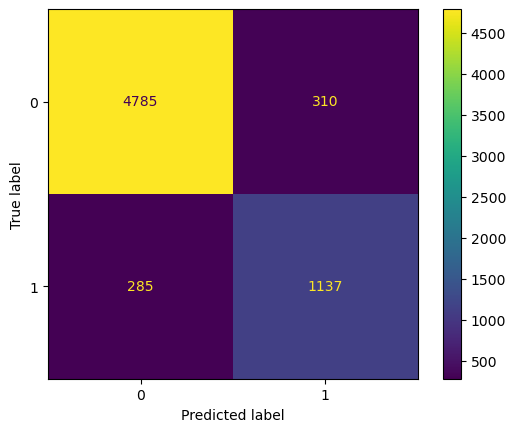

In [58]:
ml_support_obj.plot_confusion_matrix(y_test, preds, finalized_pipeline)

In [59]:
%%time
ml_support_obj.plot_learning_curves(finalized_pipeline)

CPU times: user 41.7 s, sys: 20.4 s, total: 1min 2s
Wall time: 34.1 s


In [60]:
dict_Baseline_Score = {
                "Model_Name" : "Baseline LGBMClassifier Tree Logistic",
                "Model_Pipeline" : [finalized_pipeline],
                "Score": balanced_accuracy_score(y_test, preds)
               }
df_modelPerformance = ml_support_obj.update_performance_matrics(dict_Baseline_Score,df_modelPerformance)
df_modelPerformance.sort_values('Score',ascending=False)

,Model_Name,Model_Pipeline,Score
6,Baseline LGBMClassifier Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.869367
5,Hypertuned RandomForest Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.844781
4,Baseline Radnom Forest Classifier,[(<__main__.DataframeFunctionTransformer objec...,0.843562
2,Baseline Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.831228
1,Hyper Tuned Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745860
0,Baseline Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745705
3,Hypertuned Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.734027


In [66]:
%%time
ml_support_obj = ml_support()
regression_model = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
params = {"munging__num_munging__num_missing__estimator": [LinearRegression(n_jobs=-1), RandomForestRegressor(random_state=42),KNeighborsRegressor(n_jobs=-1)],
          "model__n_estimators":  [int(x) for x in range(200,2000,200)],
          "model__learning_rate": [0.001,0.01,0.1,1,10],
          "model__boosting_type": ['gbdt','goss','dart'],
          }
ct = ml_support_obj.get_column_transformer(False, "", True)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 79.6 ms, sys: 5.58 ms, total: 85.2 ms
Wall time: 95.3 ms


In [67]:
%%time
best_params = ml_support_obj.get_best_params(finalized_pipeline,params)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END model__boosting_type=gbdt, model__learning_rate=1, model__n_estimators=1600, munging__num_munging__num_missing__estimator=LinearRegression(n_jobs=-1);, score=0.647 total time=   5.1s
[CV 2/5] END model__boosting_type=gbdt, model__learning_rate=1, model__n_estimators=1600, munging__num_munging__num_missing__estimator=LinearRegression(n_jobs=-1);, score=0.784 total time=  17.1s
[CV 3/5] END model__boosting_type=gbdt, model__learning_rate=1, model__n_estimators=1600, munging__num_munging__num_missing__estimator=LinearRegression(n_jobs=-1);, score=0.652 total time=   6.2s
[CV 4/5] END model__boosting_type=gbdt, model__learning_rate=1, model__n_estimators=1600, munging__num_munging__num_missing__estimator=LinearRegression(n_jobs=-1);, score=0.666 total time=   5.4s
[CV 5/5] END model__boosting_type=gbdt, model__learning_rate=1, model__n_estimators=1600, munging__num_munging__num_missing__estimator=LinearRegression(n_jo

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1817: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



CPU times: user 24min 9s, sys: 2min 19s, total: 26min 29s
Wall time: 12min 5s


In [68]:
best_params

{'munging__num_munging__num_missing__estimator': LinearRegression(n_jobs=-1),
 'model__n_estimators': 200,
 'model__learning_rate': 0.001,
 'model__boosting_type': 'dart'}

In [69]:
%%time
ml_support_obj = ml_support()
regression_model = LGBMClassifier(class_weight='balanced', random_state=42, 
                                  n_jobs=-1,n_estimators=200,learning_rate=0.001,
                                  boosting_type='dart'
                                 )
ct = ml_support_obj.get_column_transformer(True, LinearRegression(n_jobs=-1), False)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 75.1 ms, sys: 3.87 ms, total: 79 ms
Wall time: 162 ms


In [70]:
%%time
preds = ml_support_obj.predit_with_pipeline(finalized_pipeline,X_train,X_test,y_train)

CPU times: user 12.3 s, sys: 1.27 s, total: 13.5 s
Wall time: 6.35 s


In [71]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

Balenced Accuracy Score : 0.8363726330521775


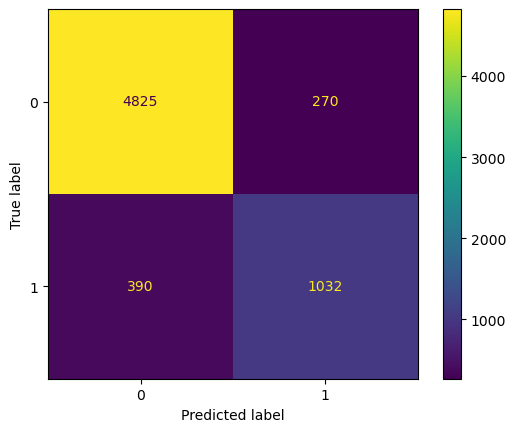

In [72]:
ml_support_obj.plot_confusion_matrix(y_test, preds, finalized_pipeline)

In [73]:
%%time
ml_support_obj.plot_learning_curves(finalized_pipeline)

CPU times: user 2min 57s, sys: 31.7 s, total: 3min 29s
Wall time: 1min 37s


In [ ]:
dict_Baseline_Score = {
                "Model_Name" : "Baseline Decision Tree Logistic",
                "Model_Pipeline" : [finalized_pipeline],
                "Score": balanced_accuracy_score(y_test, preds)
               }
df_modelPerformance = ml_support_obj.update_performance_matrics(dict_Baseline_Score,df_modelPerformance)
df_modelPerformance.sort_values('Score',ascending=False)

In [63]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

Balenced Accuracy Score : 0.8693670472002418


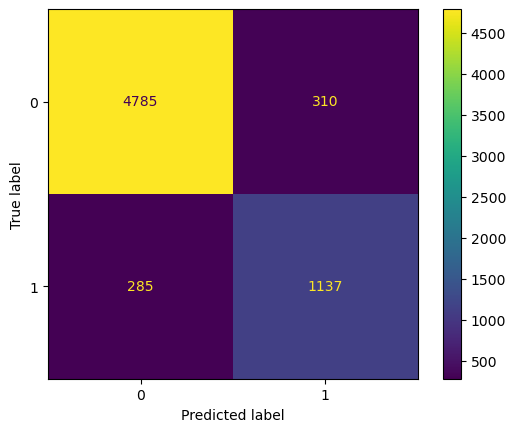

In [64]:
ml_support_obj.plot_confusion_matrix(y_test, preds, finalized_pipeline)

In [65]:
%%time
ml_support_obj.plot_learning_curves(finalized_pipeline)

CPU times: user 43.8 s, sys: 22.1 s, total: 1min 5s
Wall time: 39.4 s


In [74]:
finalized_pipeline

Pipeline(steps=[('FeatureEngineering_add_features',
                 <__main__.DataframeFunctionTransformer object at 0x7186bcb51590>),
                ('selector',
                 <__main__.SelectColumnsTransformer object at 0x7186b0415c50>),
                ('munging',
                 ColumnTransformer(transformers=[('num_munging',
                                                  Pipeline(steps=[('num_missing',
                                                                   IterativeImputer(estimator=LinearRegression(n_jobs=-1))),
                                                                  ('num_smoothening',...
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['person_hom

In [75]:
dict_Baseline_Score = {
                "Model_Name" : "Hypertuned LGBMClassifier",
                "Model_Pipeline" : [finalized_pipeline],
                "Score": balanced_accuracy_score(y_test, preds)
               }
df_modelPerformance = ml_support_obj.update_performance_matrics(dict_Baseline_Score,df_modelPerformance)
df_modelPerformance.sort_values('Score',ascending=False)


,Model_Name,Model_Pipeline,Score
6,Baseline LGBMClassifier Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.869367
5,Hypertuned RandomForest Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.844781
4,Baseline Radnom Forest Classifier,[(<__main__.DataframeFunctionTransformer objec...,0.843562
7,Hypertuned LGBMClassifier,[(<__main__.DataframeFunctionTransformer objec...,0.836373
2,Baseline Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.831228
1,Hyper Tuned Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745860
0,Baseline Logistic Regression,[(<__main__.DataframeFunctionTransformer objec...,0.745705
3,Hypertuned Decision Tree Logistic,[(<__main__.DataframeFunctionTransformer objec...,0.734027


In [87]:
model_pipeline = df_modelPerformance.loc[df_modelPerformance['Model_Name']=='Baseline LGBMClassifier Tree Logistic','Model_Pipeline'].values

In [88]:
model_pipeline

array([list([Pipeline(steps=[('FeatureEngineering_add_features',
                        <__main__.DataframeFunctionTransformer object at 0x7186bcb51590>),
                       ('selector',
                        <__main__.SelectColumnsTransformer object at 0x7186b04fdad0>),
                       ('munging',
                        ColumnTransformer(transformers=[('num_munging',
                                                         Pipeline(steps=[('num_missing',
                                                                          IterativeImputer())]),
                                                         ['person_age',
                                                          'person_income', 'loan_amnt',
                                                          'loan_percen...
                                                         Pipeline(steps=[('cat_encoding',
                                                                          OneHotEncoder(drop='if_binary'

In [ ]:
test=pd.read_csv("/kaggle/input/titanic/test.csv", encoding='latin')
submission_preds = model_pipeline[0][0].predict(test)
test_ids = test['PassengerId']
df_submit = pd.DataFrame({"PassengerId": test_ids.values,
                         "Survived" : submission_preds
                        })
df_submit.to_csv("submission.csv",index=False)

In [82]:
%%time
# Adaboost (Boosting of multiple Decision Trees)
from sklearn.ensemble import AdaBoostRegressor
ml_support_obj = ml_support()
best_decision_tree_model = RandomForestClassifier(random_state = 42,n_estimators=1200,
                                          min_samples_split=5, min_samples_leaf = 1,
                                          max_features = 'auto', max_depth = None,
                                          bootstrap =True
                                         )
regression_model = AdaBoostRegressor()
ct = ml_support_obj.get_column_transformer(False, "", True)
X_train, X_test , y_train, y_test = ml_support_obj.get_train_test_data()
finalized_pipeline = ml_support_obj.get_final_pipeline(regression_model,ct,feature_engieered)

CPU times: user 76.9 ms, sys: 0 ns, total: 76.9 ms
Wall time: 84 ms


In [83]:
%%time
preds = ml_support_obj.predit_with_pipeline(finalized_pipeline,X_train,X_test,y_train)

CPU times: user 992 ms, sys: 261 ms, total: 1.25 s
Wall time: 712 ms


In [86]:
print("Balenced Accuracy Score : {0}".format(balanced_accuracy_score(y_test, preds)))

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [84]:
ml_support_obj.plot_confusion_matrix(y_test, preds, finalized_pipeline)

AttributeError: 'AdaBoostRegressor' object has no attribute 'classes_'